# CNN-LSTM

## Preprocessing

In [4]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

In [5]:
con = duckdb.connect(database='D:/Assets/BinanceFuturesData/binancefuturesdata.duckdb', read_only=True)

In [6]:
# BTCUSDT 2025년 1월~11월의 1분봉 데이터
data_query = "SELECT epoch_ms(timestamp) as time, open, high, low, close, volume FROM quote " \
"WHERE symbol = 'BTCUSDT' " \
"and epoch_ms(timestamp) >= '2025-01-01 00:00:00' " \
"and epoch_ms(timestamp) < '2025-12-01 00:00:00' " \
"ORDER BY timestamp;"
df = con.execute(data_query).fetchdf()

con.close()

In [7]:
# 원본 데이터 크기
df.shape

(480960, 6)

In [8]:
def add_indicators(df):
    df = df.copy()
    # 1분봉이므로 노이즈가 많아 짧은/긴 이동평균선 추가
    df['ma_7'] = df['close'].rolling(window=7).mean()
    df['ma_25'] = df['close'].rolling(window=25).mean()
    df['ma_99'] = df['close'].rolling(window=99).mean()
    
    # RSI 계산
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # 볼린저 밴드 (변동성 지표)
    df['std'] = df['close'].rolling(window=20).std()
    df['upper_band'] = df['ma_25'] + (df['std'] * 2)
    df['lower_band'] = df['ma_25'] - (df['std'] * 2)
    
    # 거래량 변화율
    df['vol_change'] = df['volume'].pct_change()

    df.dropna(inplace=True) # 지표 계산으로 생긴 NaN 제거
    return df

In [9]:
# 지표 추가
df = add_indicators(df)

In [10]:
df[-5:]

,time,open,high,low,close,volume,ma_7,ma_25,ma_99,rsi,std,upper_band,lower_band,vol_change
480955,2025-11-30 23:55:00,90353.4,90402.0,90347.8,90402.0,102.526,90464.585714,90547.212,90900.955556,43.149038,91.897665,90731.007331,90363.416669,-0.466610
480956,2025-11-30 23:56:00,90401.9,90432.3,90364.3,90364.3,117.141,90438.014286,90536.732,90891.594949,28.835300,99.904251,90736.540503,90336.923497,0.142549
480957,2025-11-30 23:57:00,90364.3,90406.0,90333.3,90372.2,128.229,90409.428571,90529.016,90882.506061,31.361052,106.091167,90741.198333,90316.833667,0.094655
480958,2025-11-30 23:58:00,90372.2,90372.2,90300.0,90316.9,184.376,90380.271429,90519.676,90873.522222,25.906040,114.519476,90748.714952,90290.637048,0.437865
480959,2025-11-30 23:59:00,90316.8,90342.7,90300.0,90320.6,141.079,90357.885714,90510.228,90864.514141,21.015918,122.052339,90754.332679,90266.123321,-0.234830


Signal classification

In [11]:
# ---------------------------------------------------------
# [핵심] 분류 라벨링 (Labeling for Classification)
# 전략: 현재로부터 'N분 뒤' 가격이 'K%' 이상 오르면 매수(1), 내리면 매도(2), 아니면 관망(0)
# ---------------------------------------------------------
LOOK_AHEAD = 10      # 10분 뒤의 가격을 예측 목표로 설정
THRESHOLD = 0.002    # 0.2% 변동성 기준 (수수료 고려하여 설정 필요)

# 미래 수익률 계산 ((10분 뒤 가격 - 현재 가격) / 현재 가격)
df['future_ret'] = df['close'].shift(-LOOK_AHEAD) / df['close'] - 1

In [12]:
# 라벨 정의 함수
def get_class(ret):
    if ret > THRESHOLD:
        return 1  # Buy (Long)
    elif ret < -THRESHOLD:
        return 2  # Sell (Short)
    else:
        return 0  # Hold (No Action)

In [13]:
df['label'] = df['future_ret'].apply(get_class)

In [14]:
# 라벨링을 위해 사용한 future_ret 컬럼과 마지막 LOOK_AHEAD 만큼의 데이터(정답 없음) 제거
df.dropna(subset=['future_ret'], inplace=True)

In [15]:
# 클래스 분포 확인 (불균형 체크)
df['label'].value_counts()

label
0    394136
1     43515
2     43184
Name: count, dtype: int64

In [16]:
# 무한대(inf)를 NaN으로 변환
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# NaN이 포함된 행 제거
df.dropna(inplace=True)
# 남은 행 개수
len(df)

# 의문: 데이터는 연속된 값인데 중간에 빠져도 훈련 데이터로서 상관없는건지?

480834

Data normalization

In [17]:
# ---------------------------------------------------------
# 데이터 정규화
# ---------------------------------------------------------
# 입력 피처 선택 (시간 제외, 미래 참조 데이터 제외)
feature_cols = ['open', 'high', 'low', 'close', 'volume', 'ma_7', 'ma_25', 'ma_99', 'rsi', 'upper_band', 'lower_band', 'vol_change']
target_col = 'label'

In [18]:
# Train/Test 분리 (시계열 순서 유지)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

In [19]:
# 스케일링 (StandardScaler 권장 - 이상치에 조금 더 강함)
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_df[feature_cols])
test_X_scaled = scaler.transform(test_df[feature_cols])

In [20]:
# 타겟은 스케일링 하지 않음 (0, 1, 2 정수이므로)
train_y_raw = train_df[target_col].values
test_y_raw = test_df[target_col].values

Sequence data conversion

In [21]:
# 시퀀스 생성 함수
def create_dataset(X, y, time_steps=60):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps]) # 시퀀스 끝나는 시점의 라벨
    return np.array(Xs), np.array(ys)

In [22]:
TIME_STEPS = 60 # 과거 60분(1시간) 데이터를 보고 판단

X_train, y_train_int = create_dataset(train_X_scaled, train_y_raw, TIME_STEPS)
X_test, y_test_int = create_dataset(test_X_scaled, test_y_raw, TIME_STEPS)

One-Hot Encoding

In [23]:
# ---------------------------------------------------------
# One-Hot Encoding (분류 모델 필수)
# 0 -> [1, 0, 0], 1 -> [0, 1, 0], 2 -> [0, 0, 1]
# ---------------------------------------------------------
y_train = to_categorical(y_train_int, num_classes=3)
y_test = to_categorical(y_test_int, num_classes=3)

In [24]:
# 전처리 결과 출력
print(f"입력 데이터 형태 (X_train): {X_train.shape}  -> (샘플 수, {TIME_STEPS}분, {len(feature_cols)}개 특징)")
print(f"출력 데이터 형태 (y_train): {y_train.shape}  -> (샘플 수, 3개 클래스)")
print(f"테스트 데이터 형태 (X_test): {X_test.shape}")

입력 데이터 형태 (X_train): (384607, 60, 12)  -> (샘플 수, 60분, 12개 특징)
출력 데이터 형태 (y_train): (384607, 3)  -> (샘플 수, 3개 클래스)
테스트 데이터 형태 (X_test): (96107, 60, 12)


Class weight process

In [25]:
# 클래스 불균형이 심해서 클래스 가중치 계산해서 변수에 저장하는 단계가 필요
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ---------------------------------------------------------
# 클래스 가중치 계산 (Class Weight Calculation)
# 목적: 데이터가 적은 Buy(1)/Sell(2) 클래스에 더 큰 중요도를 부여하여
#      모델이 "무조건 Hold(0)"만 찍는 것을 방지함.
# ---------------------------------------------------------

# 1) One-Hot Encoding된 y_train([0, 1, 0])을 다시 정수([1])로 변환
# 이유: compute_class_weight 함수는 1차원 정수 배열을 입력으로 받기 때문
y_train_int = np.argmax(y_train, axis=1)

# 2) 존재하는 클래스 종류 확인 (0: Hold, 1: Buy, 2: Sell)
classes = np.unique(y_train_int)

# 3) 가중치 계산 ('balanced' 모드 사용)
# 공식: n_samples / (n_classes * np.bincount(y))
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_int
)

# 4) Keras 모델 학습 시 전달할 딕셔너리 형태로 변환 {0: 0.4..., 1: 3.7..., 2: 3.7...}
class_weights = dict(zip(classes, weights))

In [26]:
# 클래스 가중치 계산 결과
print(f"클래스(Key): {list(class_weights.keys())}")
print(f"가중치(Value): {list(class_weights.values())}")
print("-" * 40)
print(f"Hold(0) 가중치: {class_weights[0]:.4f} (데이터가 많으므로 낮음)")
print(f"Buy (1) 가중치: {class_weights[1]:.4f} (데이터가 적으므로 높음)")
print(f"Sell(2) 가중치: {class_weights[2]:.4f} (데이터가 적으므로 높음)")
print("-" * 40)

# 이제 이 'class_weights' 변수를 model.fit() 함수에 전달하면 됨

클래스(Key): [0, 1, 2]
가중치(Value): [0.4025810354915932, 3.826821089917714, 3.9259633542591743]
----------------------------------------
Hold(0) 가중치: 0.4026 (데이터가 많으므로 낮음)
Buy (1) 가중치: 3.8268 (데이터가 적으므로 높음)
Sell(2) 가중치: 3.9260 (데이터가 적으므로 높음)
----------------------------------------


## Model architecture

**가장 일반적인 직렬 아키텍처는 1D CNN 블록이 먼저 지역적 특징을 추출하고, 그 출력이 LSTM 블록으로 전달되어 시간적 종속성을 학습하는 형태**

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
def build_cnn_lstm_model(input_shape, num_classes):
    model = Sequential()
    
    # [1] 1D CNN Block: 캔들의 국소적인 패턴(급등, 급락, 특정 모양) 추출
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization()) # 학습 안정화
    model.add(MaxPooling1D(pool_size=2)) # 중요 특징만 남기고 차원 축소
    model.add(Dropout(0.3)) # 과적합 방지

    # [2] LSTM Block: 추출된 패턴의 시간적 흐름 학습
    # 1D CNN의 출력은 (Time, Feature) 형태이므로 LSTM에 바로 연결 가능
    model.add(LSTM(units=64, return_sequences=False)) # 마지막 시점의 판단만 필요하므로 False
    model.add(Dropout(0.3))

    # [3] Dense Block: 최종 분류
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    
    # Output Layer: 3개 클래스 확률 출력 (Softmax)
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

In [27]:
# ---------------------------------------------------------
# 모델 아키텍처 설계 (Architecture Design)
# 구조: Input -> Conv1D (패턴 추출) -> LSTM (시계열 분석) -> Dense (분류)
# ---------------------------------------------------------

# 입력 형태 정의 (60분, 12개 특징)
TIME_STEPS = X_train.shape[1]
N_FEATURES = X_train.shape[2]
INPUT_SHAPE = (TIME_STEPS, N_FEATURES)
NUM_CLASSES = 3  # Hold, Buy, Sell

# 모델 생성
model = build_cnn_lstm_model(INPUT_SHAPE, NUM_CLASSES)

C:\Users\Gaten\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# ---------------------------------------------------------
# 모델 컴파일 (Compile)
# ---------------------------------------------------------
# Optimizer: 시계열에 강한 Adam, 학습률 0.001
# Loss: 다중 분류이므로 categorical_crossentropy
# Metrics: 불균형 데이터이므로 '정확도' 외에 Precision(정밀도), Recall(재현율) 필수 확인
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# 모델 구조 요약
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 58, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,827 (147.76 KB)

 Trainable params: 37,699 (147.26 KB)

 Non-trainable params: 128 (512.00 B)

In [29]:
# ---------------------------------------------------------
# 모델 학습 (Training with Class Weights)
# ---------------------------------------------------------

# 콜백 설정: 
# 1. EarlyStopping: 검증 손실(val_loss)이 5번 연속 안 줄어들면 학습 조기 종료
# 2. ModelCheckpoint: 가장 성능 좋은 모델 자동 저장
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_btc_bot_model.keras', monitor='val_loss', save_best_only=True)
]

print("\n--- 학습 시작 ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,             # 최대 50번 반복 (EarlyStopping으로 일찍 끝날 수 있음)
    batch_size=64,         # 한번에 학습할 데이터 양
    class_weight=class_weights,  # ★ 핵심: 아까 계산한 가중치 적용
    callbacks=callbacks,
    verbose=1
)

print("\n--- 학습 완료 ---")


--- 학습 시작 ---
Epoch 1/50
6010/6010 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - accuracy: 0.6255 - loss: 1.0041 - precision: 0.9049 - recall: 0.3496 - val_accuracy: 0.6928 - val_loss: 0.8828 - val_precision: 0.8867 - val_recall: 0.3258
Epoch 2/50
6010/6010 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - accuracy: 0.6434 - loss: 0.9921 - precision: 0.9209 - recall: 0.3583 - val_accuracy: 0.6622 - val_loss: 0.8841 - val_precision: 0.9145 - val_recall: 0.3541
Epoch 3/50
6010/6010 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - accuracy: 0.6466 - loss: 0.9895 - precision: 0.9194 - recall: 0.3604 - val_accuracy: 0.6393 - val_loss: 0.9336 - val_precision: 0.9156 - val_recall: 0.2764
Epoch 4/50
6010/6010 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - accuracy: 0.6460 - loss: 0.9869 - precision: 0.9247 - recall: 0.3686 - val_accuracy: 0.6773 - val_loss: 0.8801 - val_precision: 0.8886 - val_recall: 0.4014
Epoch 5/50
6010/6010 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - accuracy: 0.6446 - loss: 0.9854 - precision: 0.9254 - recall: 0.3730 - val_a

- 입력 레이어: (시퀀스 길이 T, 특징 수 F) 형태의 입력.
- 1D CNN 블록 (특징 추출):
- Conv1D 레이어: 시퀀스를 따라 슬라이딩하며 단기적이고 지역적인 패턴 (예: 캔들 패턴, 갑작스러운 거래량 급증)을 추출합니다. 필터 수, 커널 크기, 활성화 함수(ReLU 권장)를 설정합니다.
- MaxPooling1D 또는 AveragePooling1D 레이어: 추출된 특징의 차원을 줄이고 가장 중요한 특징을 선택합니다.
- (선택적) 여러 Conv1D 레이어를 쌓아 계층적 특징을 추출할 수 있습니다.
- 데이터 형태 변환 (RepeatVector 또는 TimeDistributed):CNN의 출력을 LSTM의 입력에 맞게 시퀀스 형태로 변환합니다.
- 일반적으로 CNN의 출력을 RepeatVector를 통해 $T'$ 시간 단계만큼 반복하여 LSTM에 전달하거나, TimeDistributed 래퍼를 사용하여 각 시간 단계에 CNN을 적용할 수 있습니다.
- LSTM 블록 (시퀀스 모델링):
- LSTM 레이어: CNN에서 추출된 특징의 장기적인 시간적 종속성과 추세 변화를 학습합니다. 유닛 수와 return_sequences 설정(여러 LSTM을 쌓을 경우)을 지정합니다.
- 출력 레이어:
- 회귀: Dense 레이어 1개 (활성화 함수: linear).
- 분류: Dense 레이어 3개 (매수/매도/보류인 경우) (활성화 함수: Softmax).

## Training & Validation

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [31]:
# ---------------------------------------------------------
# 학습 결과 시각화 (Loss & Accuracy)
# ---------------------------------------------------------
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.legend()
    
    # Precision 그래프 (정확도보다 중요)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['precision'], label='Train Precision')
    plt.plot(history.history['val_precision'], label='Val Precision')
    plt.title('Precision Curve')
    plt.legend()
    
    plt.show()

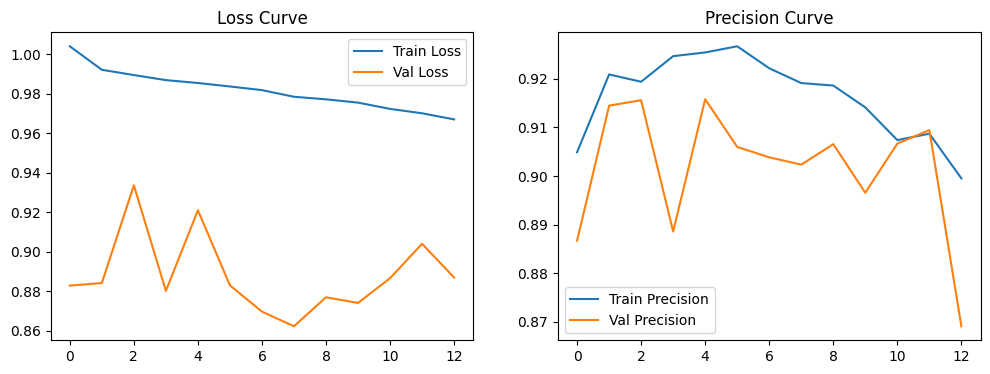

In [32]:
plot_history(history)


--- 예측 수행 중... ---
3004/3004 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


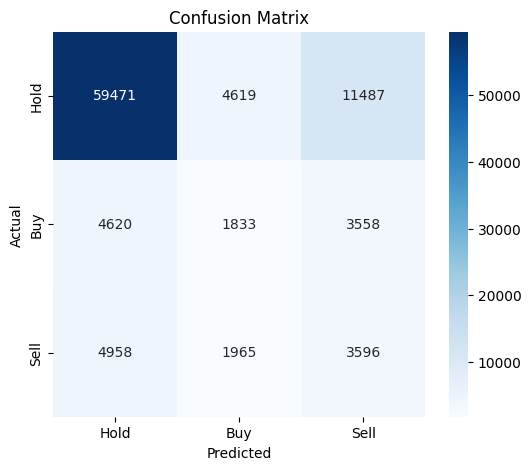


--- 상세 분류 리포트 ---
              precision    recall  f1-score   support

        Hold       0.86      0.79      0.82     75577
         Buy       0.22      0.18      0.20     10011
        Sell       0.19      0.34      0.25     10519

    accuracy                           0.68     96107
   macro avg       0.42      0.44      0.42     96107
weighted avg       0.72      0.68      0.69     96107



In [33]:
# ---------------------------------------------------------
# 모델 평가 및 혼동 행렬 (Confusion Matrix)
# ---------------------------------------------------------

# 저장된 최고 성능 모델 불러오기
best_model = tf.keras.models.load_model('best_btc_bot_model.keras')

# 테스트 데이터 예측
print("\n--- 예측 수행 중... ---")
pred_probs = best_model.predict(X_test)
pred_classes = np.argmax(pred_probs, axis=1) # 확률 -> 0, 1, 2 클래스로 변환
true_classes = np.argmax(y_test, axis=1)     # 정답 데이터

# 혼동 행렬 시각화
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hold', 'Buy', 'Sell'], 
            yticklabels=['Hold', 'Buy', 'Sell'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 상세 리포트 출력
print("\n--- 상세 분류 리포트 ---")
print(classification_report(true_classes, pred_classes, target_names=['Hold', 'Buy', 'Sell']))

In [34]:
# ---------------------------------------------------------
# 백테스팅 (Backtesting Simulation)
# ---------------------------------------------------------
# 간단한 로직: Buy 신호 시 전량 매수, Sell 신호 시 전량 매도
# ---------------------------------------------------------

initial_balance = 10000.0  # 초기 자본 $10,000
balance = initial_balance
position = 0               # 코인 보유량
fee_rate = 0.0004          # 수수료 0.04% (Binance Taker 기준)
portfolio_value = []       # 자산 가치 기록

# 테스트 데이터의 실제 가격 정보 가져오기 (전처리 전 df 사용 필요)
# 주의: test_df는 위 전처리 과정에서 정의된 원본 데이터 프레임이어야 함
test_close_prices = test_df['close'].values[TIME_STEPS:] # 시퀀스 길이만큼 앞부분 제외됨

print("\n--- 백테스팅 시작 (초기 자본: $10,000) ---")

for i in range(len(pred_classes)):
    action = pred_classes[i]
    current_price = test_close_prices[i]
    
    # 매수 (Buy) 신호
    if action == 1: 
        if balance > 0: # 현금이 있으면
            buy_amount = balance / current_price
            fee = balance * fee_rate
            position = buy_amount * (1 - fee_rate) # 수수료 차감 후 코인 보유
            balance = 0
            # print(f"매수: {current_price:.2f} USDT")

    # 매도 (Sell) 신호
    elif action == 2:
        if position > 0: # 코인이 있으면
            sell_amount = position * current_price
            fee = sell_amount * fee_rate
            balance = sell_amount - fee # 수수료 차감 후 현금 보유
            position = 0
            # print(f"매도: {current_price:.2f} USDT")
            
    # Hold는 아무것도 안함
    
    # 현재 총 자산 가치 기록
    current_val = balance + (position * current_price)
    portfolio_value.append(current_val)

# 최종 결과
final_balance = portfolio_value[-1]
roi = ((final_balance - initial_balance) / initial_balance) * 100

print(f"최종 자산: ${final_balance:.2f}")
print(f"수익률 (ROI): {roi:.2f}%")


--- 백테스팅 시작 (초기 자본: $10,000) ---
최종 자산: $3545.89
수익률 (ROI): -64.54%


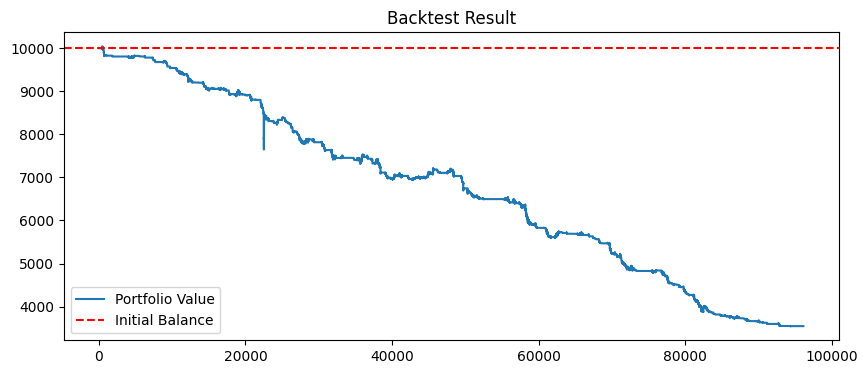

In [35]:
# 수익률 그래프
plt.figure(figsize=(10, 4))
plt.plot(portfolio_value, label='Portfolio Value')
plt.axhline(y=initial_balance, color='r', linestyle='--', label='Initial Balance')
plt.title('Backtest Result')
plt.legend()
plt.show()

- 손실 함수 (Loss Function):
- 회귀: MSE (Mean Squared Error) 또는 MAE (Mean Absolute Error).
- 분류: Categorical Cross-Entropy (원-핫 인코딩 시).
- 최적화 도구 (Optimizer): Adam, RMSprop 등을 사용합니다.
- 훈련: 훈련 데이터셋으로 모델을 훈련시키고, 검증 데이터셋으로 과적합을 모니터링합니다. Early Stopping을 적용하여 성능 향상이 없을 때 훈련을 중단합니다.
- 평가 지표:
- 회귀: RMSE, R-squared.
- 분류: 정확도(Accuracy), 정밀도(Precision), 재현율(Recall), F1-Score, 백테스팅 수익률.

## Backtesting



Signal generation
- 훈련된 모델은 실시간 데이터(또는 백테스팅 데이터)를 입력받아 예측 가격 또는 트레이딩 신호(매수/매도/보류)를 출력합니다.
- 신호 해석:
- 가격 예측 기반: 예측 가격이 현재 가격보다 일정 임계값 이상 높으면 '매수', 낮으면 '매도', 그 외는 '보류'로 해석하는 로직을 추가해야 합니다.
- 분류 기반: 모델이 예측한 신호를 직접 트레이딩 액션으로 사용합니다.

Backtesting
- 시뮬레이션 환경: 과거 데이터를 사용하여 모델의 트레이딩 전략을 시뮬레이션합니다.
- 핵심 지표: 총 수익률, 최대 낙폭(MDD, Maximum Drawdown), 샤프 비율(Sharpe Ratio), 승률 등을 분석하여 전략의 안정성과 수익성을 평가합니다.

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
# ---------------------------------------------------------
# 확률 임계값(Threshold) 적용 백테스팅
# 목적: 모델이 '긴가민가' 할 때는 거래하지 않고, '확실하다' 할 때만 거래
# ---------------------------------------------------------

# 예측 확률 가져오기 (이미 위에서 pred_probs = best_model.predict(X_test) 수행함)
# pred_probs 형태: [[0.8, 0.1, 0.1], [0.2, 0.7, 0.1], ...]

# 설정: 이 확률 이상일 때만 진입 (아주 보수적으로 설정)
CONFIDENCE_THRESHOLD = 0.55  # 80% 이상 확신할 때만 거래

# 새로운 예측 클래스 생성
final_actions = []

hold_count = 0
buy_count = 0
sell_count = 0

for probs in pred_probs:
    max_prob = np.max(probs)      # 가장 높은 확률값
    predicted_class = np.argmax(probs) # 0, 1, 2
    
    # 임계값을 넘지 못하면 무조건 Hold(0) 처리
    if max_prob < CONFIDENCE_THRESHOLD:
        final_actions.append(0)
        hold_count += 1
    else:
        final_actions.append(predicted_class)
        if predicted_class == 1: buy_count += 1
        elif predicted_class == 2: sell_count += 1
        else: hold_count += 1

print(f"\n--- 임계값 {CONFIDENCE_THRESHOLD * 100}% 적용 후 신호 분포 ---")
print(f"Hold: {hold_count}회")
print(f"Buy : {buy_count}회 (필터링 전보다 대폭 감소 예상)")
print(f"Sell: {sell_count}회")


--- 임계값 55.00000000000001% 적용 후 신호 분포 ---
Hold: 96082회
Buy : 25회 (필터링 전보다 대폭 감소 예상)
Sell: 0회


In [41]:
# ---------------------------------------------------------
# 다시 백테스팅 (로직 동일)
# ---------------------------------------------------------
initial_balance = 10000.0
balance = initial_balance
position = 0
fee_rate = 0.0004
portfolio_value = []
# test_close_prices는 이전 코드에서 정의된 변수를 사용합니다.
test_close_prices = test_df['close'].values[TIME_STEPS:] 

trade_log = [] 

for i in range(len(final_actions)):
    action = final_actions[i]
    current_price = test_close_prices[i]
    
    # Buy Signal (1)
    if action == 1: 
        if balance > 0:
            # (매매 로직 생략)
            buy_amount = balance / current_price
            fee = balance * fee_rate
            position = buy_amount * (1 - fee_rate)
            balance = 0
            trade_log.append(f"BUY at {current_price:.2f}")

    # Sell Signal (2)
    elif action == 2:
        if position > 0:
            # (매매 로직 생략)
            sell_amount = position * current_price
            fee = sell_amount * fee_rate
            balance = sell_amount - fee
            position = 0
            trade_log.append(f"SELL at {current_price:.2f}")
            
    current_val = balance + (position * current_price)
    portfolio_value.append(current_val)

# 결과 출력
final_balance = portfolio_value[-1]
roi = ((final_balance - initial_balance) / initial_balance) * 100

print("\n--- 필터링 후 백테스팅 결과 ---")
print(f"최종 자산: ${final_balance:.2f}")
print(f"수익률 (ROI): {roi:.2f}%")
print(f"총 거래 횟수: {len(trade_log)}")


--- 필터링 후 백테스팅 결과 ---
최종 자산: $8240.52
수익률 (ROI): -17.59%
총 거래 횟수: 1
